# <div><center>**CUSTOMER CHURN ANALYSIS & PREDICTION**</center></div>
---


This notebook conducts a comprehensive analysis of customer churn prediction using the Customer_Churn_Data dataset.
The objective of this project is to  identify patterns influencing customer churn and develop a predictive model to help businesses reduce churn and improve customer retention.

The notebook workflow follows:

- <u>**Data Loading and Cleaning**</u>

    - Importing the dataset and handling missing values.
    - Applying data transformation techniques to ensure consistency.

- <u>**Exploratory Data Analysis (EDA)**</u>

    - Understanding the structure of the dataset, key variables and descriptive statistics.
    - Visualizing key patterns, such as overall churn, churn rates across different customer segments.

- <u>**Feature Engineering and Selection**</u>

    - Encoding categorical variables for model compatibility.
    - Extracting the target and feature variables from the dataset.

- **<u>Model Selection, Development and Evaluation**</u>

    - Training multiple classification models to predict churn.
    - Comparing models using metrics such as accuracy, recall, precision, and F1-score.

- **<u>Hyperparameter Tuning**</u>

    - Optimizing the selected model using grid search and threshold adjustments.
    - Balancing class weights to address data imbalances.

---

---
### **LOADING THE DATASET**

In [12]:
# Importing the libraries and loading the data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)
df = pd.read_csv("Data/Customer_Churn_Data.csv")
df.head(3)

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,Yes,Cable,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,Yes,Cable,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,Yes,Fiber Optic,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices


---
### **DATA EXPLORATION AND CLEANING**

In [13]:
df.shape

(6418, 32)

The dataset contains 6418 rows and 32 columns

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6418 entries, 0 to 6417
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6418 non-null   object 
 1   Gender                       6418 non-null   object 
 2   Age                          6418 non-null   int64  
 3   Married                      6418 non-null   object 
 4   State                        6418 non-null   object 
 5   Number_of_Referrals          6418 non-null   int64  
 6   Tenure_in_Months             6418 non-null   int64  
 7   Value_Deal                   2870 non-null   object 
 8   Phone_Service                6418 non-null   object 
 9   Multiple_Lines               5796 non-null   object 
 10  Internet_Service             6418 non-null   object 
 11  Internet_Type                5028 non-null   object 
 12  Online_Security              5028 non-null   object 
 13  Online_Backup     

In [15]:
df.describe(include='all')

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
count,6418,6418,6418.000000,6418,6418,6418.000000,6418.000000,2870,6418,5796,6418,5028,5028,5028,5028,5028,5028,5028,5028,5028,6418,6418,6418,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418,1732,1732
unique,6418,2,NaN,2,22,NaN,NaN,5,2,2,2,3,2,2,2,2,2,2,2,2,3,2,3,NaN,NaN,NaN,NaN,NaN,NaN,3,5,20
top,19877-DEL,Female,NaN,No,Uttar Pradesh,NaN,NaN,Deal 2,Yes,No,Yes,Fiber Optic,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,NaN,NaN,NaN,NaN,NaN,NaN,Stayed,Competitor,Competitor had better devices
freq,1,4048,NaN,3223,629,NaN,NaN,758,5796,3082,5028,2764,3204,2820,2817,3172,2556,2520,2766,4334,3286,3792,3575,NaN,NaN,NaN,NaN,NaN,NaN,4275,761,289
mean,NaN,NaN,47.070739,NaN,NaN,7.427859,17.342786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.652867,2280.374858,1.924944,6.718604,748.703468,3033.871987,NaN,NaN,NaN
std,NaN,NaN,16.703633,NaN,NaN,4.621519,10.576391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.188823,2268.049985,7.849083,24.722533,847.672844,2866.505426,NaN,NaN,NaN
min,NaN,NaN,18.000000,NaN,NaN,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000,NaN,NaN,NaN
25%,NaN,NaN,33.000000,NaN,NaN,3.000000,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.562500,395.725000,0.000000,0.000000,70.805000,603.742500,NaN,NaN,NaN
50%,NaN,NaN,46.000000,NaN,NaN,7.000000,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.100000,1396.125000,0.000000,0.000000,407.475000,2108.635000,NaN,NaN,NaN
75%,NaN,NaN,60.000000,NaN,NaN,11.000000,27.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.750000,3783.600000,0.000000,0.000000,1182.917500,4801.537500,NaN,NaN,NaN


Majority of the columns having null values have only 2 unique values 'Yes' & 'No' so we will are filling those with no or none, and all of the numerical columns have no null values so there is no need to fill them. In case of churn category and reason we need to analyse it further.

In [16]:
df[['Churn_Category']].value_counts()

Churn_Category 
Competitor         761
Attitude           301
Dissatisfaction    300
Price              196
Other              174
dtype: int64

In [17]:
df[['Churn_Reason']].value_counts()

Churn_Reason                             
Competitor had better devices                289
Competitor made better offer                 274
Attitude of support person                   208
Don't know                                   124
Competitor offered more data                 106
Attitude of service provider                  93
Competitor offered higher download speeds     92
Price too high                                72
Product dissatisfaction                       71
Network reliability                           66
Long distance charges                         62
Service dissatisfaction                       61
Moved                                         45
Extra data charges                            34
Limited range of services                     33
Poor expertise of online support              30
Lack of affordable download/upload speed      28
Lack of self-service on Website               27
Poor expertise of phone support               12
Deceased                   

Replacing all the null values with others in both the columns

In [18]:
# Filling the null values with appropriate values for each columns
df['Value_Deal'].fillna('None',inplace=True)
df['Multiple_Lines'].fillna('No',inplace=True)
df['Internet_Type'].fillna('None',inplace=True)
df['Online_Security'].fillna('No',inplace=True)
df['Online_Backup'].fillna('No',inplace=True)
df['Device_Protection_Plan'].fillna('No',inplace=True)
df['Premium_Support'].fillna('No',inplace=True)
df['Streaming_TV'].fillna('No',inplace=True)
df['Streaming_Movies'].fillna('No',inplace=True)
df['Streaming_Music'].fillna('No',inplace=True)
df['Unlimited_Data'].fillna('No',inplace=True)
df['Churn_Category'].fillna('Others',inplace=True)
df['Churn_Reason'].fillna('Others',inplace=True)

---
### **EXPLORATORY DATA ANALYSIS**

In [19]:
df.describe()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
count,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000
mean,47.070739,7.427859,17.342786,63.652867,2280.374858,1.924944,6.718604,748.703468,3033.871987
std,16.703633,4.621519,10.576391,31.188823,2268.049985,7.849083,24.722533,847.672844,2866.505426
min,18.000000,0.000000,1.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,33.000000,3.000000,8.000000,30.562500,395.725000,0.000000,0.000000,70.805000,603.742500
50%,46.000000,7.000000,16.000000,70.100000,1396.125000,0.000000,0.000000,407.475000,2108.635000
75%,60.000000,11.000000,27.000000,89.750000,3783.600000,0.000000,0.000000,1182.917500,4801.537500
max,85.000000,15.000000,36.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [20]:
df.describe(include='object')

,Customer_ID,Gender,Married,State,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Customer_Status,Churn_Category,Churn_Reason
count,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418,6418
unique,6418,2,2,22,6,2,2,2,4,2,2,2,2,2,2,2,2,3,2,3,3,6,21
top,19877-DEL,Female,No,Uttar Pradesh,None,Yes,No,Yes,Fiber Optic,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Stayed,Others,Others
freq,1,4048,3223,629,3548,5796,3704,5028,2764,4594,4210,4207,4562,3946,3910,4156,4334,3286,3792,3575,4275,4686,4686


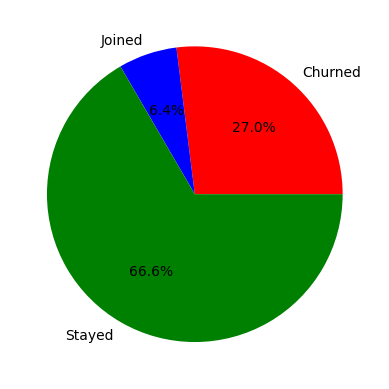

In [21]:
# Customer status distribution
customer_status = df.groupby('Customer_Status').count()['Customer_ID']
plt.pie(customer_status,
        labels=customer_status.index,
        autopct='%1.1f%%',
        colors=['red','blue','green'])
plt.show()

Churn Rate is 27% 

C:\Users\91626\AppData\Local\Temp\ipykernel_42752\653789402.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='Churn_Category', data=df.loc[(df['Customer_Status'] == 'Churned')],palette='bright')


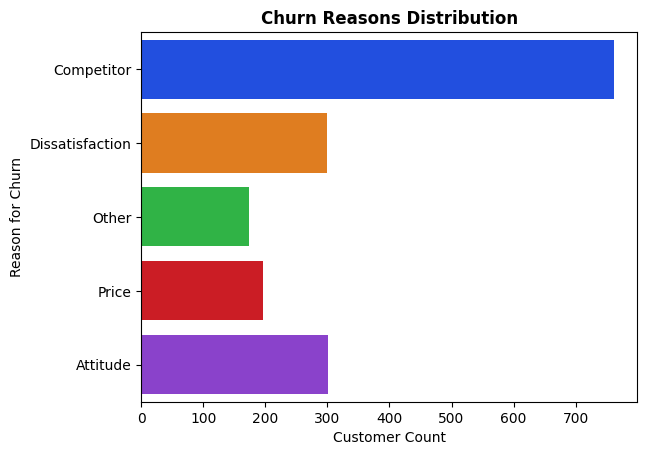

In [22]:
ax = sns.countplot(y='Churn_Category', data=df.loc[(df['Customer_Status'] == 'Churned')],palette='bright')
plt.xlabel('Customer Count')
plt.ylabel('Reason for Churn')
plt.title('Churn Reasons Distribution',fontweight='bold')
plt.show()


The 2 Main Reasons behind customers churn are competitors and dissatisfaction of the customers so we need to develop strategies to counter the competitors and imporve our services to decrease the customer satisfaction

---
### **MODEL TRAINING AND EVALUATION**

In [23]:
# Extracting both featur and target variable
modeling_data = df[df['Customer_Status'].isin(['Stayed','Churned'])]
modeling_data.drop(['Customer_ID','Churn_Category','Churn_Reason'],axis=1,inplace=True)
modeling_data.reset_index(inplace=True,drop=True)
target_variable = modeling_data.pop('Customer_Status').to_frame() # this is also categorical column
feature_variables = modeling_data
categorical_columns = feature_variables.select_dtypes('object').columns.to_list()



C:\Users\91626\AppData\Local\Temp\ipykernel_42752\1031411398.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  modeling_data.drop(['Customer_ID','Churn_Category','Churn_Reason'],axis=1,inplace=True)


In [24]:
# Encoding all the categorical variables since the machine learning model can only work with numerical data
from sklearn.preprocessing import LabelEncoder
encoders = {}
encoding_and_value = {}
encoding_summary = []

for col in categorical_columns:
    encoders[col] = LabelEncoder()
    feature_variables[col] = encoders[col].fit_transform(feature_variables[col])
    encoding_dict = {encoding : value for value,encoding in enumerate(encoders[col].classes_)}
    encoding_and_value[col] = encoding_dict
    for label, index in encoding_dict.items():
        encoding_summary.append(f"Column '{col}': '{label}' encoded to {index}")

target_variable['Customer_Status'] = target_variable['Customer_Status'].map({'Stayed':0,'Churned':1})

C:\Users\91626\AppData\Local\Temp\ipykernel_42752\3885469017.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_variables[col] = encoders[col].fit_transform(feature_variables[col])
C:\Users\91626\AppData\Local\Temp\ipykernel_42752\3885469017.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_variables[col] = encoders[col].fit_transform(feature_variables[col])
C:\Users\91626\AppData\Local\Temp\ipykernel_42752\3885469017.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of

In [25]:
# Using lazypredict to fit all the classifciation models at once 
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split,KFold,cross_val_score
x = feature_variables
y = target_variable
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=1)
classifier = LazyClassifier(random_state=1)
model,prediction = classifier.fit(x_train,x_test,y_train,y_test)
print(model)



100%|██████████| 31/31 [00:11<00:00,  2.74it/s]

[LightGBM] [Info] Number of positive: 1392, number of negative: 3413
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000525 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 4805, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.289698 -> initscore=-0.896850
[LightGBM] [Info] Start training from score -0.896850
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
AdaBoostClassifier                 0.84               0.79     0.79      0.84   
LGBMClassifier                     0.85               0.79     0.79      0.84   
XGBClassifier                      0.84               0.78     0.78      0.84   
RandomForestClassifier             0.85 

Selecting the Light gradient boositng classifier as it can also handle unscaled data and outliersdue to its tree bassed structure

In [26]:
# Training the model
from lightgbm import LGBMClassifier
model = LGBMClassifier(force_col_wise=True)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

[LightGBM] [Info] Number of positive: 1392, number of negative: 3413
[LightGBM] [Info] Total Bins 1348
[LightGBM] [Info] Number of data points in the train set: 4805, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.289698 -> initscore=-0.896850
[LightGBM] [Info] Start training from score -0.896850


In [27]:
# Evlauatiing the model
from sklearn.metrics import confusion_matrix,classification_report
confusion_matrix = confusion_matrix(y_true=y_test,y_pred=y_pred)
classification_report = classification_report(y_true=y_test,y_pred=y_pred)
feature_importances = model.feature_importances_
feature_indices = np.argsort(feature_importances)[::-1]
print(f'Confusion Matrix : \n{confusion_matrix}\n')
print(f'Classification Report : \n{classification_report}\n')

Confusion Matrix : 
[[810  52]
 [120 220]]

Classification Report : 
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       862
           1       0.81      0.65      0.72       340

    accuracy                           0.86      1202
   macro avg       0.84      0.79      0.81      1202
weighted avg       0.85      0.86      0.85      1202




The recall score of the positive class (Churned) is 65% that is the model is only able to identify 65% of the churned customers & accuracy is 81% that is out of all the predicted churned 81% actually churned.

---
### **HYPERPARAMETER TUNING**

[LightGBM] [Info] Number of positive: 1392, number of negative: 3413
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001192 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1348
[LightGBM] [Info] Number of data points in the train set: 4805, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.472928 -> initscore=-0.108393
[LightGBM] [Info] Start training from score -0.108393
Confusion Matrix : 
[[752 110]
 [ 86 254]]

Classification Report : 
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       862
           1       0.70      0.75      0.72       340

    accuracy                           0.84      1202
   macro avg       0.80      0.81      0.80      1202
weighted avg       0.84      0.84      0.84      1202




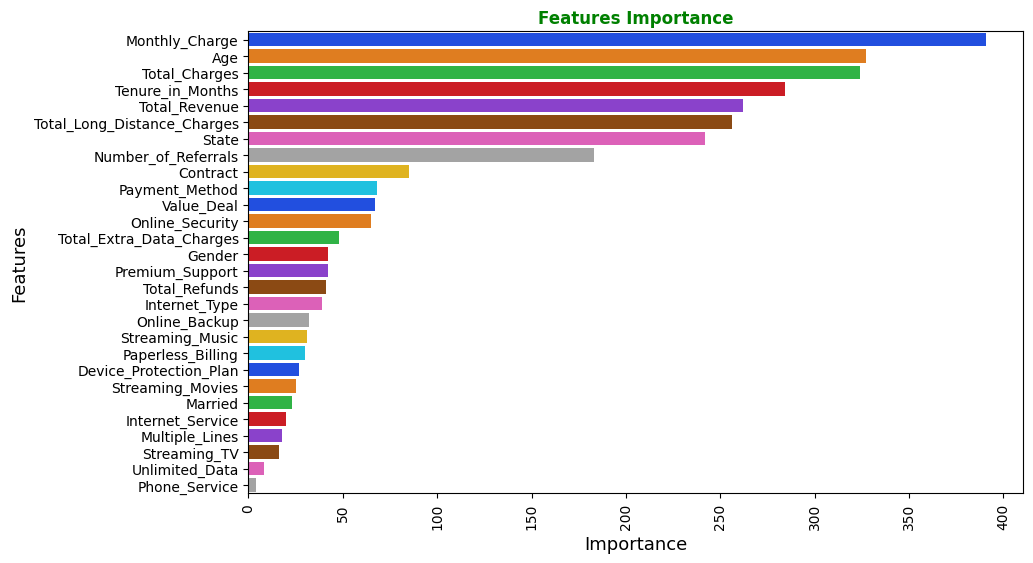

In [28]:
from sklearn.metrics import confusion_matrix,classification_report
# Training the LGBMClassifier Model
model = LGBMClassifier(class_weight={0: 5, 1: 11}) # Using both under & overweighting to fix class imbalances
model.fit(x_train, y_train)

# Predicting probabilities for churners
y_probs = model.predict_proba(x_test)[:, 1]

# Adjusting  the  threshold
threshold = 0.45 # reducing the threshold to 45% from defalult of 50%
y_pred_threshold = (y_probs >= threshold).astype(int)

# Evaluation Metrics 
confusion_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred_threshold)
classification_report = classification_report(y_true=y_test, y_pred=y_pred_threshold)
feature_importances = model.feature_importances_
feature_indices = np.argsort(feature_importances)[::-1]
print(f'Confusion Matrix : \n{confusion_matrix}\n')
print(f'Classification Report : \n{classification_report}\n')
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances[feature_indices],y=x.columns[feature_indices],palette='bright')
plt.xlabel('Importance',fontsize=13,y=-0.3)
plt.ylabel('Features',fontsize=13)
plt.xticks(rotation=90)
plt.title('Features Importance',fontweight='bold',color='green')
plt.show()

After finetuning the model the recall score has improved by 10% now model can identify correctly 75% of all churned customers.

---
### **MODEL SAVING AND PREDICTION**

In [ ]:
# Using joblib's dump function to save the model for future usage
from joblib import dump
dump(model,"Model/Churn_Classifier.joblib")

In [30]:
joiners_data = df[df['Customer_Status'] == 'Joined']
prediction_data = joiners_data.copy()
id = prediction_data['Customer_ID']
prediction_data = prediction_data.drop(['Customer_ID','Churn_Category','Churn_Reason','Customer_Status'],axis=1)


for column in prediction_data.select_dtypes(object).columns:
    prediction_data[column] = encoders[column].transform(prediction_data[column])

y_probs = model.predict_proba(prediction_data)[:, 1]
threshold = 0.45
joiners_predicted_threshold = (y_probs >= threshold).astype(int)
joiners_data['Predicted Status'] = joiners_predicted_threshold
churned_customers = joiners_data[joiners_data['Predicted Status'] == 1]
churned_customers.to_csv("Output/Predicted Data.csv",index=False)

---
### **CREDITS AND CONTACT**

**Created by:** Krishna Kasera  
**GitHub:** [https://github.com/Krishna-Kasera](https://github.com/Krishna-Kasera) | **Contact:** KKasera025@outlook.com